In [54]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/food.csv")
df.tail()

,Unnamed: 0,Menu,Energy (kJ),Protein (g),Fat (g),Carbohydrates (g),Dietary Fiber (g),PUFA (g),Cholesterol (mg),Vitamin A (mg),...,Vitamin B6 (mg),Total Folic Acid (µg),Vitamin C (mg),Sodium (mg),Potassium (mg),Calcium (mg),Magnesium (mg),Phosphorus (mg),Iron (mg),Zinc (mg)
1179,1179,Tahu Bacem,"100,56","1,9","1,47","1,09",0,0.0,3.0,0.0,...,0.0,0,0.0,34,4,0,0.0,3,0.0,0.0
1180,1180,Promina Puff Blueberry,"334,6",1,3,10,0,0.0,0.0,0.0,...,0.0,0,0.0,0,0,4,4.0,5,0.0,0.0
1181,1181,Kentang Rebus,"317,68","1,37","0,14","17,72","2,5",0.0,0.0,0.0,...,0.0,0,0.0,27,0,0,0.0,0,0.0,9.0
1182,1182,Jasuke,"359,38","3,22","1,18","19,02",0,0.0,0.0,0.0,...,0.0,0,0.0,0,6,6,4.0,0,0.0,0.0
1183,1183,Chicken Nugget,"1240,47","15,58","18,82","16,32",0,0.0,39.0,0.0,...,0.0,0,0.0,574,26,0,0.0,29,0.0,0.0


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1184 entries, 0 to 1183
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             1184 non-null   int64  
 1   Menu                   1184 non-null   str    
 2   Energy (kJ)            1184 non-null   str    
 3   Protein (g)            1184 non-null   str    
 4   Fat (g)                1184 non-null   str    
 5   Carbohydrates (g)      1184 non-null   str    
 6   Dietary Fiber (g)      1184 non-null   str    
 7   PUFA (g)               1184 non-null   float64
 8   Cholesterol (mg)       1184 non-null   float64
 9   Vitamin A (mg)         1184 non-null   float64
 10  Vitamin E (eq.) (mg)   1184 non-null   float64
 11  Vitamin B1 (mg)        1184 non-null   float64
 12  Vitamin B2 (mg)        1184 non-null   float64
 13  Vitamin B6 (mg)        1184 non-null   float64
 14  Total Folic Acid (µg)  1184 non-null   int64  
 15  Vitamin C (mg) 

,Unnamed: 0,PUFA (g),Cholesterol (mg),Vitamin A (mg),Vitamin E (eq.) (mg),Vitamin B1 (mg),Vitamin B2 (mg),Vitamin B6 (mg),Total Folic Acid (µg),Vitamin C (mg),Potassium (mg),Calcium (mg),Magnesium (mg),Phosphorus (mg),Iron (mg),Zinc (mg)
count,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000,1184.000000
mean,591.500000,2.076182,41.168074,220.389105,0.906149,0.102475,0.171242,0.188750,32.693412,8.570524,276.098818,80.315034,34.217230,126.361486,2.232432,1.059206
std,341.935666,4.468790,149.978380,1437.183878,2.067367,0.447306,1.148374,0.457013,75.263233,17.455362,350.461019,224.660062,55.100652,179.462947,6.933195,4.122171
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,295.750000,0.100000,0.000000,0.000000,0.000000,0.020000,0.020000,0.040000,4.000000,0.000000,68.000000,6.000000,8.000000,21.000000,0.300000,0.200000
50%,591.500000,0.200000,0.000000,6.000000,0.000000,0.060000,0.060000,0.090000,12.000000,1.000000,175.000000,12.000000,19.000000,62.000000,0.700000,0.400000
75%,887.250000,1.200000,25.000000,50.000000,1.000000,0.100000,0.140000,0.250000,29.250000,9.000000,356.000000,48.000000,32.000000,161.000000,1.500000,1.025000
max,1183.000000,35.000000,2054.000000,20357.000000,24.000000,15.000000,38.000000,14.000000,608.000000,184.000000,3805.000000,1904.000000,611.000000,1456.000000,97.900000,134.000000


In [4]:
df = df.drop(columns=['Unnamed: 0'])

In [44]:
features = [
'Energy (kJ)',
'Protein (g)',
'Fat (g)',
'Carbohydrates (g)',
'Vitamin C (mg)',
'Calcium (mg)',
'Dietary Fiber (g)',
'Iron (mg)'
]

X = df[features]
print(df[features].dtypes)

Energy (kJ)          float64
Protein (g)          float64
Fat (g)              float64
Carbohydrates (g)    float64
Vitamin C (mg)       float64
Calcium (mg)           int64
Dietary Fiber (g)    float64
Iron (mg)            float64
dtype: object


In [45]:
for col in features:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
    )

    df[col] = pd.to_numeric(df[col], errors='coerce')

In [47]:

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(1174, 8)


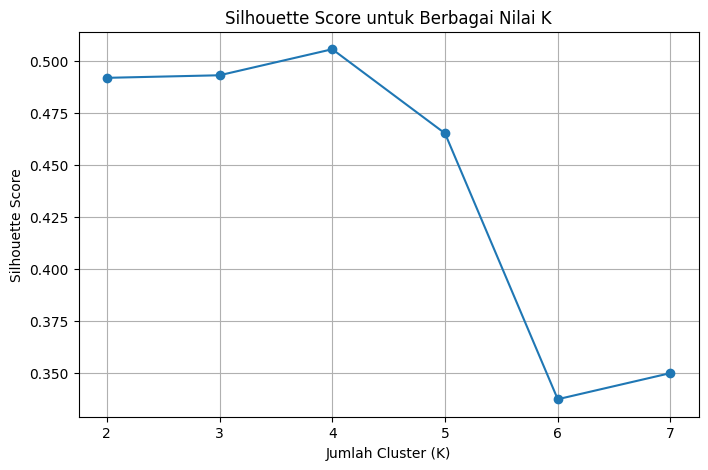

In [59]:
k_values = range(2, 8)
scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(k_values, scores, marker='o')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score untuk Berbagai Nilai K')
plt.grid(True)
plt.show()

In [57]:
cluster_summary = df.groupby('cluster')[features].mean()
print(cluster_summary)

         Energy (kJ)  Protein (g)    Fat (g)  Carbohydrates (g)  \
cluster                                                           
0        1630.170213    28.527660  14.582979          39.012766   
1         469.826552     7.908818   4.294372          11.004089   
2        1540.315950     6.434409  10.813620          64.732616   
3        2879.647222    13.748056  66.158611          13.103056   

         Vitamin C (mg)  Calcium (mg)  Dietary Fiber (g)  Iron (mg)  
cluster                                                              
0             28.063830   1025.553191           4.889362  16.010638  
1              7.783867     28.620690           1.181404   1.394458  
2              8.752688     75.555556           3.673835   2.417204  
3              1.027778     53.944444           4.633889   2.088889  


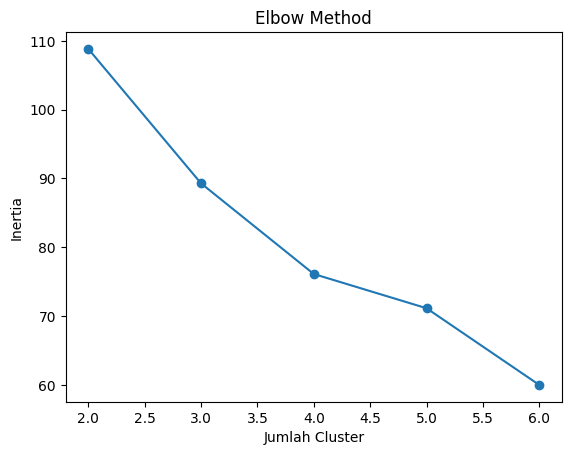

In [49]:
inertia = []

for k in range(2,7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,7), inertia, marker='o')
plt.xlabel("Jumlah Cluster")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [50]:
df[['Menu','Energy (kJ)','Protein (g)','Fat (g)','Carbohydrates (g)','Vitamin C (mg)', 'Calcium (mg)', 'Dietary Fiber (g)', 'Iron (mg)', 'cluster']].tail()

,Menu,Energy (kJ),Protein (g),Fat (g),Carbohydrates (g),Vitamin C (mg),Calcium (mg),Dietary Fiber (g),Iron (mg),cluster
1179,Tahu Bacem,100.56,1.90,1.47,1.09,0.0,0,0.0,0.0,1
1180,Promina Puff Blueberry,334.60,1.00,3.00,10.00,0.0,4,0.0,0.0,1
1181,Kentang Rebus,317.68,1.37,0.14,17.72,0.0,0,2.5,0.0,1
1182,Jasuke,359.38,3.22,1.18,19.02,0.0,6,0.0,0.0,1
1183,Chicken Nugget,1240.47,15.58,18.82,16.32,0.0,0,0.0,0.0,1


In [51]:
df['cluster'].value_counts()

cluster
1    812
2    279
0     47
3     36
Name: count, dtype: int64

In [52]:
df['Menu'] = df['Menu'].str.title()
print("Jumlah data:", len(df))

print("\nDuplikat:")
print(df['Menu'].value_counts()[df['Menu'].value_counts() > 1])

print("\nNama mengandung ?:")
print(df[df['Menu'].str.contains(r'\?', na=False)]['Menu'])

print("\nTotal nama unik:")
print(df['Menu'].nunique())

Jumlah data: 1174

Duplikat:
Series([], Name: count, dtype: int64)

Nama mengandung ?:
Series([], Name: Menu, dtype: str)

Total nama unik:
1174
